# A2.2 神经网络中损失函数的非凸性分析:均方误差vs交叉熵
在本Notebook中，我将尝试以一个简单的1-1-1结构的两层神经网络为例，分别采用均方误差损失函数和交叉熔损失函数，说明这两种函数关于参数的非凸性(可作图示意和说明)。下边这段代码定义了我们的简单神经网络，并使用`torchviz`库创建了网络结构的可视化：

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
from torchviz import make_dot
from IPython.display import display, Image

In [3]:
# 定义一个简单的1-1-1结构的双层网络结构
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(1, 1)
        self.output = nn.Linear(1, 1)
        self.activation = nn.Sigmoid()
    
    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.output(x)
        return x

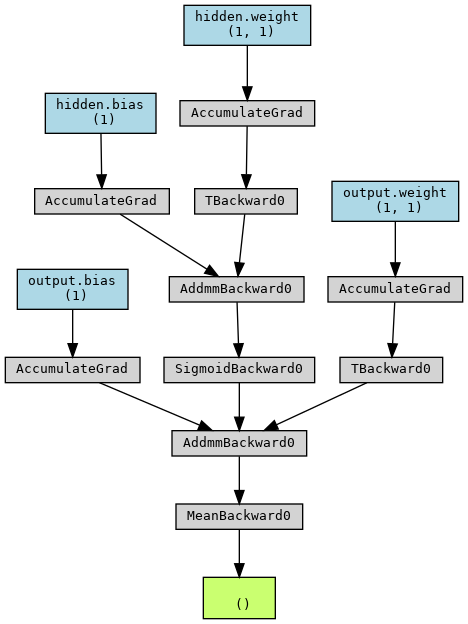

In [4]:
# 创建模型实例
model = SimpleNN()
x = torch.randn(1, 1)
y = model(x)

# 生成网络结构图
dot = make_dot(y.mean(), params=dict(model.named_parameters()))
dot.render("simple_nn", format="png", cleanup=True)
display(Image("simple_nn.png"))

## 2. 损失函数定义
下边给出我们将要研究的两种损失函数的定义:均方误差(MSE)和交叉熵。
### 1. 均方误差 (Mean Squared Error, MSE)

均方误差是回归问题中最常用的损失函数之一。它测量预测值与真实值之间的平均平方差。

对于单个样本，MSE定义如下:

$$MSE = (y - \hat{y})^2$$

其中:
- $y$ 是真实值
- $\hat{y}$ 是预测值

对于一个包含 $n$ 个样本的数据集，MSE的数学定义为:

$$MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

其中:
- $n$ 是样本数量
- $y_i$ 是第 $i$ 个样本的真实值
- $\hat{y}_i$ 是第 $i$ 个样本的预测值

### 2. 交叉熵 (Cross-Entropy)

交叉熵损失函数通常用于分类问题，特别是在输出层使用softmax激活函数的神经网络中。

#### 二分类问题

对于二分类问题，交叉熵损失函数的数学定义为:

$$H(y, \hat{y}) = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

其中:
- $y$ 是真实标签 (0 或 1)
- $\hat{y}$ 是预测的概率 (0 到 1 之间的值)

#### 多分类问题

对于多分类问题，假设有 $K$ 个类别,交叉熵损失函数的数学定义为:

$$H(y, \hat{y}) = -\sum_{c=1}^K y_c \log(\hat{y_c})$$

其中:
- $K$ 是类别的数量
- $y_c$ 是真实标签的one-hot编码 (对于真实类别为1，其他为0)
- $\hat{y_c}$ 是类别 $c$ 的预测概率

对于一个包含 $n$ 个样本的数据集,多分类问题的平均交叉熵损失为:

$$H(y, \hat{y}) = -\frac{1}{n} \sum_{i=1}^n \sum_{c=1}^K y_{ic} \log(\hat{y_{ic}})$$

其中:
- $n$ 是样本数量
- $y_{ic}$ 是第 $i$ 个样本属于类别 $c$ 的真实标签 (0 或 1)
- $\hat{y_{ic}}$ 是模型预测第 $i$ 个样本属于类别 $c$ 的概率

使用Python实现如下：

In [5]:
def mse_loss(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

def cross_entropy_loss(y_pred, y_true):
    return -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred)).mean()

## 3. 非凸性分析
### 3.1. 理论解释
从数学角度来看,非凸性主要源于神经网络的非线性激活函数(在我们的例子中是Sigmoid函数)和多层结构。对于我们的1-1-1网络,输出可以表示为:
$$y = w_2 \sigma(w_1x + b_1) + b_2$$
其中 $\sigma$ 是Sigmoid函数， $w_1, w_2$ 是权重， $b_1, b_2$ 是偏置。

这个复合函数的性质导致了损失函数关于参数的非凸性。即使是这样一个简单的网络，其损失函数也可能有多个局部最小值。
#### 3.2 模拟与可视化
为了分析这些损失函数的非凸性，下边创建一个函数来计算损失landscape，将改变网络的两个权重参数，并观察损失函数的变化。

In [6]:
def compute_loss_landscape(model, loss_fn, x, y_true, w1_range, w2_range):
    w1_values = np.linspace(w1_range[0], w1_range[1], 100)
    w2_values = np.linspace(w2_range[0], w2_range[1], 100)
    w1_grid, w2_grid = np.meshgrid(w1_values, w2_values)
    loss_grid = np.zeros_like(w1_grid)

    for i in range(w1_grid.shape[0]):
        for j in range(w1_grid.shape[1]):
            model.hidden.weight.data[0][0] = torch.tensor(w1_grid[i, j])
            model.output.weight.data[0][0] = torch.tensor(w2_grid[i, j])
            y_pred = model(x)
            loss = loss_fn(y_pred, y_true)
            loss_grid[i, j] = loss.item()
    
    return w1_grid, w2_grid, loss_grid

In [7]:
# 生成示例数据
x = torch.tensor([[0.5]])
y_true = torch.tensor([[1.0]])

# 计算MSE损失landscape
model_mse = SimpleNN()
w1_grid_mse, w2_grid_mse, loss_grid_mse = compute_loss_landscape(model_mse, mse_loss, x, y_true, (-5, 5), (-5, 5))

# 计算交叉熵损失landscape
model_ce = SimpleNN()
w1_grid_ce, w2_grid_ce, loss_grid_ce = compute_loss_landscape(model_ce, cross_entropy_loss, x, y_true, (-5, 5), (-5, 5))

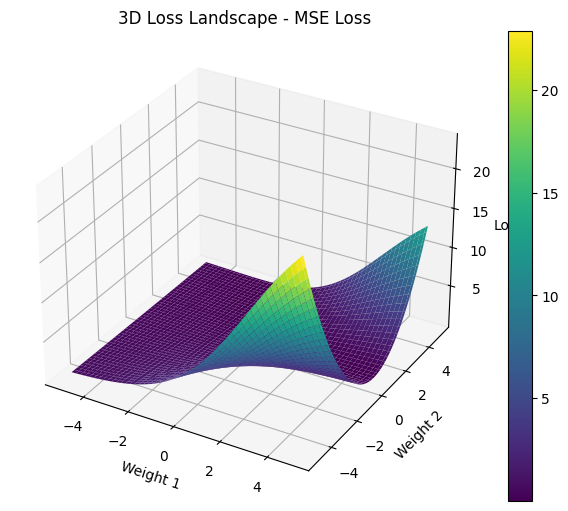

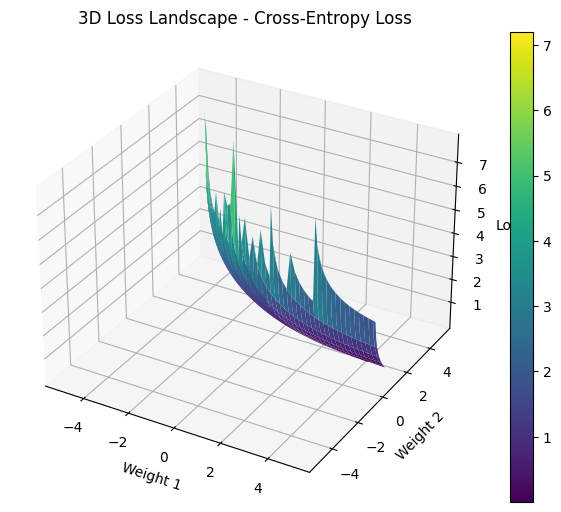

In [8]:
def plot_loss_landscape(w1_grid, w2_grid, loss_grid, title):
    fig = plt.figure(figsize=(12, 5))
    
    # 3D surface plot
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(w1_grid, w2_grid, loss_grid, cmap='viridis')
    ax1.set_xlabel('Weight 1')
    ax1.set_ylabel('Weight 2')
    ax1.set_zlabel('Loss')
    ax1.set_title(f'3D Loss Landscape - {title}')
    fig.colorbar(surf)

    plt.tight_layout()
    plt.show()

# 绘制MSE损失landscape
plot_loss_landscape(w1_grid_mse, w2_grid_mse, loss_grid_mse, "MSE Loss")

# 绘制交叉熵损失landscape
plot_loss_landscape(w1_grid_ce, w2_grid_ce, loss_grid_ce, "Cross-Entropy Loss")

通过观察生成的损失landscapes，我们不难:
1. **非凸性**: 
   - 两种损失函数都显示出非凸的特性。这意味着损失函数表面存在多个局部最小值，这使得优化过程变得复杂。
2. **MSE vs 交叉熵**:
   - MSE损失函数通常表现出更"平滑"的landscape，而交叉熵损失函数往往有更陡峭的梯度。
   - 交叉熵损失函数在某些区域可能表现出更大的曲率，这可能导致在训练过程中梯度更新更加剧烈。
3. **优化挑战**:
   - 非凸性意味着基于梯度的优化方法(如随机梯度下降)可能会陷入局部最小值，而不是全局最小值。
   - 损失landscape的形状会影响优化算法的性能和收敛速度。
4. **初始化的重要性**:
   - 由于存在多个局部最小值，网络权重的初始化变得极其重要。不同的初始化可能导致优化过程收敂到不同的局部最小值。
5. **学习率选择**:
   - 损失函数的非凸性也影响了学习率的选择。在陡峭区域，较小的学习率可能更合适，而在平坦区域，较大的学习率可能更有效。

## 结论
通过这个简单的1-1-1神经网络例子，我们探索了均方误差和交叉熵损失函数的非凸性。这种非凸性是深度学习中的一个基本挑战，理解它对于设计和优化神经网络至关重要。在实际应用中，网络通常比我们的示例复杂得多，这使得损失landscape更加复杂。然而，本NoteBook讨论的基本原理和见解仍然适用。

通过查阅资料，我们可以通过以下与上述讨论有关的方式优化深度学习的训练过程与性能：
1. **使用随机初始化**: 多次使用不同的随机初始化训练模型，选择性能最佳的一个。

2. **采用高级优化器**: 如Adam，RMSprop等，这些优化器能够更好地处理非凸优化问题。

3. **学习率调度**: 使用学习率衰减或动态调整策略来适应损失landscape的不同区域。

4. **正则化技术**: L1/L2正则化，Dropout等可以帮助平滑损失landscape。